# **Импорты**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import os
from tensorflow.keras.preprocessing import image
import gdown
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


# **Загрузка и распаковка датасета**

In [ ]:
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)
!unzip -q hw_pro.zip

# **Загрузка изображений**

In [ ]:
base_dir = '/content/hw_pro'
x_train = []
y_train = []
img_height, img_width = 20, 20

for patch in os.listdir(base_dir):
    for img in os.listdir(os.path.join(base_dir, patch)):
        img_path = os.path.join(base_dir, patch, img)
        img_array = image.img_to_array(
            image.load_img(img_path, target_size=(img_height, img_width), color_mode='grayscale')
        )
        x_train.append(img_array)
        # метки: 0 для папки '0' (крестик), 1 для папки '1' (нолик)
        y_train.append(0 if patch == '0' else 1)

x_train = np.array(x_train, dtype=np.float32)
y_train = np.array(y_train, dtype=np.int64)
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")

x_train shape: (102, 20, 20, 1), y_train shape: (102,)


# **Предобработка**

In [ ]:
# Нормализация
x_train = x_train / 255.0
x_train_flat = x_train.reshape(x_train.shape[0], -1)  # (102, 400)

# Разделение на train/val (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    x_train_flat, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# Преобразование в тензоры
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

# Создаем даталоадеры
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# **Определение модели**

In [ ]:
class ProNet(nn.Module):
    def __init__(self):
        super(ProNet, self).__init__()
        self.fc1 = nn.Linear(400, 256)
        self.drop1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 128)
        self.drop2 = nn.Dropout(0.3)
        self.fc3 = nn.Linear(128, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.drop1(x)
        x = self.relu(self.fc2(x))
        x = self.drop2(x)
        x = self.fc3(x)
        return x

model = ProNet().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# **Обучение с early stopping**

In [ ]:
best_val_acc = 0.0
patience = 10
counter = 0
num_epochs = 100
history = {'train_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
    val_acc = correct / total

    history['train_loss'].append(train_loss / len(train_loader))
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss = {train_loss/len(train_loader):.4f}, Val Acc = {val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'pro_best.weights.pt')  # сохраняем лучшие веса
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping на эпохе {epoch+1}")
            break

Epoch 1: Train Loss = 0.6921, Val Acc = 0.4762
Epoch 2: Train Loss = 0.6916, Val Acc = 0.4762
Epoch 3: Train Loss = 0.6877, Val Acc = 0.4762
Epoch 4: Train Loss = 0.7014, Val Acc = 0.4762
Epoch 5: Train Loss = 0.6884, Val Acc = 0.4762
Epoch 6: Train Loss = 0.7023, Val Acc = 0.4762
Epoch 7: Train Loss = 0.7003, Val Acc = 0.4762
Epoch 8: Train Loss = 0.6940, Val Acc = 0.4762
Epoch 9: Train Loss = 0.6919, Val Acc = 0.4762
Epoch 10: Train Loss = 0.6916, Val Acc = 0.4762
Epoch 11: Train Loss = 0.6892, Val Acc = 0.4762
Early stopping на эпохе 11


# **Загрузка лучших весов и финальная оценка**

In [ ]:
model.load_state_dict(torch.load('pro_best.weights.pt'))
model.eval()
with torch.no_grad():
    outputs = model(X_val_t.to(device))
    _, predicted = torch.max(outputs, 1)
    final_acc = (predicted == y_val_t.to(device)).float().mean().item()
print(f"\n✅ Лучшая точность на валидации: {final_acc:.4f}")

if final_acc >= 0.95:
    print("🎉 Цель достигнута! Точность выше 95%.")
else:
    print("⚠️ Точность ниже 95%. Попробуйте изменить архитектуру или гиперпараметры.")


✅ Лучшая точность на валидации: 0.4762
⚠️ Точность ниже 95%. Попробуйте изменить архитектуру или гиперпараметры.


# **График обучения**

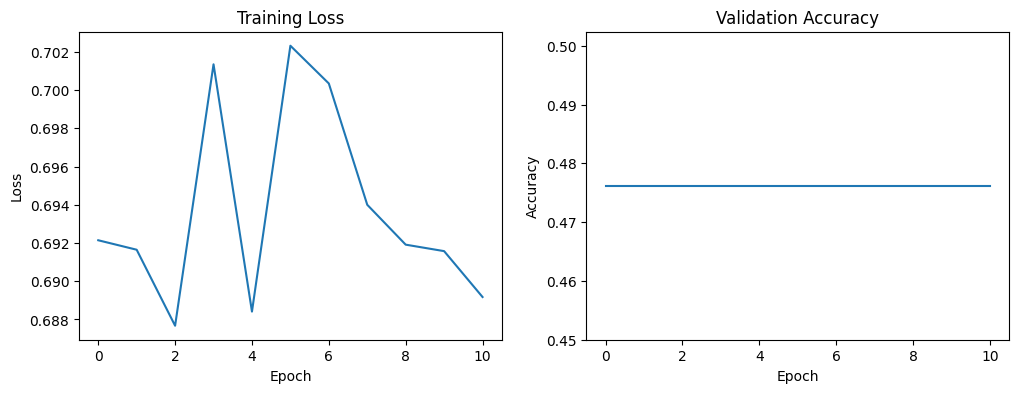

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'])
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1,2,2)
plt.plot(history['val_acc'])
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()